# Experiment 02 — LSH–Euclidean Correlation Under Controlled Synthetic Gradient Perturbations

This notebook diagnoses when LSHFed-style Hamming distance does and does not track Euclidean distance.

From this experiment, we find that Hamming distance is sensitive to direction/angular structure, but not at all sensitive to magnitude scaling. Euclidean distance, on the other hand, is sensitive to both direction and magnitude.

Thus, in cases where two gradients have a difference in magnitude alongside a difference in angular deviation, the Hamming-Euclidean correlation can break.

The experiment separates three cases for diagnosis:

1. **Magnitude-only scaling:** same direction, different scale.
2. **Directional perturbation:** increasing angular deviation from a common base gradient.
3. **Synthetic population:** random perturbations in angular deviation, followed by an `r` sweep.

The goal is to understand why high Hamming–Euclidean correlation appears in some controlled settings while failing in others. The experiment does not try to force the maximization of correlation.


## 1. Setup and reproducibility

The notebook is self-contained. So it doesn't need Google Drive (any environment setup works), external datasets (the dataset is downloaded automatically), or a clone of the authors' repository (relevant functions are implemented exactly as the authors' original code wherever required, but without having to clone the whole repo). 

All synthetic projection vectors are generated from fixed seeds.



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr, spearmanr

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Results directory:", RESULTS_DIR.resolve())


PyTorch: 2.10.0+cpu
Results directory: /mnt/data/results


## 2. LSHFed-compatible hashing

These functions exactly reproduce the relevant functions in the authors' released `lsh.py`. `flatten_to_2d` flattens the model tensors into 2D, `lsh_hash` projects each column of the flattened gradient matrix against a random vector and thresholds the dot product with `dot > 0`, and finally `hamming_distance` counts the number of unequal hash bits (basically an XOR operation).



In [2]:
def flatten_to_2d(tensor):
    """Match LSHFed's tensor flattening convention."""
    if tensor.dim() == 1:
        return tensor.view(-1, 1)
    if tensor.dim() == 2:
        return tensor
    return tensor.view(tensor.size(0), -1)


def lsh_hash(gradient, random_vectors):
    """Generate LSHFed-style binary hashes as a compact Boolean tensor."""
    grad_2d = flatten_to_2d(gradient.detach().cpu())
    hashes = []

    for rand_vec in random_vectors:
        dots = torch.mv(grad_2d.t(), rand_vec)
        hashes.append(dots > 0)

    return torch.stack(hashes)


def hamming_distance(hash1, hash2):
    """Count unequal bits between two LSH hash tensors."""
    if hash1.shape != hash2.shape:
        raise ValueError(
            f"Hash shapes must match, got {hash1.shape} and {hash2.shape}."
        )

    return torch.count_nonzero(hash1 != hash2).item()


## 3. Base synthetic gradient and fixed projection bank

The base gradient has a shape of `64 × 128`. Thus under LSHFed, for each random projection vector to be dot-producted with a gradient column, it must have a length of `64`. And a full gradient projection of all columns produces a hash string of `128` bits.

A single fixed bank of 256 random vectors is generated once. Smaller `r` values are later retrieved from this same bank, so differences across varying `r` values are not confounded by any other variable.


In [3]:
torch.manual_seed(2026)

SYN_ROWS = 64
SYN_COLS = 128
BASE = torch.randn(SYN_ROWS, SYN_COLS, dtype=torch.float32)

SYN_R = 256
torch.manual_seed(777)
SYN_PROJECTIONS = [
    torch.randn(SYN_ROWS, dtype=torch.float32)
    for _ in range(SYN_R)
]

print("Base shape:", BASE.shape)
print("Projection-vector shape:", SYN_PROJECTIONS[0].shape)
print("Maximum r:", SYN_R)
print("Hash bits at r=256:", SYN_R * SYN_COLS)


Base shape: torch.Size([64, 128])
Projection-vector shape: torch.Size([64])
Maximum r: 256
Hash bits at r=256: 32768


## 4. Sanity check A — magnitude-only scaling

For positive scale factors $s$, construct

$$g_s = sB.$$

From the result of this sanity check, we see that while Euclidean distance grows with scale / magnitude, Hamming distance is not affected by it.

With no directional change, increasing the magnitude increases Euclidean distance while Hamming distance stays at zero.


In [4]:
magnitude_scales = [1.00, 1.01, 1.05, 1.10, 1.50, 2.00]
magnitude_gradients = [BASE * scale for scale in magnitude_scales]

base_hash = lsh_hash(BASE, SYN_PROJECTIONS)
magnitude_rows = []

for scale, gradient in zip(magnitude_scales, magnitude_gradients):
    euclidean = torch.norm(BASE - gradient, p=2).item()
    gradient_hash = lsh_hash(gradient, SYN_PROJECTIONS)
    hamming = hamming_distance(base_hash, gradient_hash)

    magnitude_rows.append({
        "scale": scale,
        "euclidean_distance": euclidean,
        "hamming_distance": hamming,
    })

magnitude_df = pd.DataFrame(magnitude_rows)
magnitude_df.to_csv(RESULTS_DIR / "magnitude_scaling.csv", index=False)
magnitude_df


,scale,euclidean_distance,hamming_distance
0,1.00,0.000000,0
1,1.01,0.902803,0
2,1.05,4.514016,0
3,1.10,9.028043,0
4,1.50,45.140202,0
5,2.00,90.280403,0


**Observation.** This shows that Hamming and Euclidean distances do not always necessarily correlate. We see that two gradients can have exactly identical LSH hashes, despite being far apart in Euclidean magnitude.


## 5. Sanity check B — directional perturbation

Next, we take a noise direction $N$ and increasingly perturb the gradient towards that angular deviation, such that 

$$g_\alpha = B + \alpha N.$$

The intention of increasing $\alpha$ is to increase the angular deviation of the gradient.

From this check, we find that Hamming distance now increases alongside Euclidean distance.


In [5]:
torch.manual_seed(314159)
NOISE = torch.randn_like(BASE)

noise_levels = [0.00, 0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
directional_gradients = [BASE + alpha * NOISE for alpha in noise_levels]

directional_rows = []

for alpha, gradient in zip(noise_levels, directional_gradients):
    euclidean = torch.norm(BASE - gradient, p=2).item()
    gradient_hash = lsh_hash(gradient, SYN_PROJECTIONS)
    hamming = hamming_distance(base_hash, gradient_hash)
    normalized = hamming / (SYN_R * SYN_COLS)

    directional_rows.append({
        "noise_level": alpha,
        "euclidean_distance": euclidean,
        "hamming_distance": hamming,
        "normalized_hamming": normalized,
    })

directional_df = pd.DataFrame(directional_rows)
directional_df.to_csv(RESULTS_DIR / "directional_perturbation.csv", index=False)
directional_df


,noise_level,euclidean_distance,hamming_distance,normalized_hamming
0,0.00,0.000000,0,0.000000
1,0.01,0.904792,93,0.002838
2,0.05,4.523959,487,0.014862
3,0.10,9.047917,987,0.030121
4,0.25,22.619799,2508,0.076538
5,0.50,45.239594,4783,0.145966
6,1.00,90.479187,8113,0.247589


**Observation.** Unlike pure scaling, directional perturbation produces increasing Hamming distance. Together, the two sanity checks show that the behavior of Hamming distance is only tied to angular/directional change, whereas Euclidean distance also contains magnitude information.


## 6. Controlled synthetic population

Generate 200 gradients of the form

$$g_i = B + \alpha_i N_i,$$

where $\alpha_i \sim U(0,1)$ (the level or strength of perturbation) and each $N_i$ (the angular direction of perturbation) is independent Gaussian noise.


In [6]:
torch.manual_seed(271828)
NUM_SYNTHETIC = 200

synthetic_gradients = []
synthetic_alphas = []

for _ in range(NUM_SYNTHETIC):
    alpha = torch.rand(1).item()
    noise = torch.randn_like(BASE)
    synthetic_gradients.append(BASE + alpha * noise)
    synthetic_alphas.append(alpha)

print("Synthetic gradients:", len(synthetic_gradients))


Synthetic gradients: 200


## 7. Pairwise Euclidean and Hamming distances at `r = 256`

There are `200 choose 2 = 19,900` unique gradient pairs. Euclidean distance is computed once per pair and reused later in the `r` sweep.


In [7]:
synthetic_hashes = [
    lsh_hash(gradient, SYN_PROJECTIONS)
    for gradient in synthetic_gradients
]

pair_indices = []
synthetic_euclidean = []
synthetic_hamming = []

for i in range(NUM_SYNTHETIC):
    if i % 25 == 0:
        print(f"Processing {i}/{NUM_SYNTHETIC}")

    for j in range(i + 1, NUM_SYNTHETIC):
        pair_indices.append((i, j))
        synthetic_euclidean.append(
            torch.norm(synthetic_gradients[i] - synthetic_gradients[j], p=2).item()
        )
        synthetic_hamming.append(
            hamming_distance(synthetic_hashes[i], synthetic_hashes[j])
        )

synthetic_euclidean = np.asarray(synthetic_euclidean)
synthetic_hamming = np.asarray(synthetic_hamming)
synthetic_normalized = synthetic_hamming / (SYN_R * SYN_COLS)

pairwise_df = pd.DataFrame({
    "gradient_i": [i for i, _ in pair_indices],
    "gradient_j": [j for _, j in pair_indices],
    "euclidean_distance": synthetic_euclidean,
    "hamming_distance_r256": synthetic_hamming,
    "normalized_hamming_r256": synthetic_normalized,
})
pairwise_df.to_csv(RESULTS_DIR / "pairwise_distances_r256.csv", index=False)

print("Number of pairs:", len(pair_indices))


Processing 0/200
Processing 25/200
Processing 50/200


Processing 75/200
Processing 100/200
Processing 125/200
Processing 150/200
Processing 175/200


Number of pairs: 19900


In [ ]:
synthetic_pearson, _ = pearsonr(synthetic_euclidean, synthetic_hamming)
synthetic_spearman, _ = spearmanr(synthetic_euclidean, synthetic_hamming)

print(f"Pearson correlation:  {synthetic_pearson:.4f}")
print(f"Spearman correlation: {synthetic_spearman:.4f}")


Pearson correlation:  0.9944
Spearman correlation: 0.9964
Note: normalizing Hamming distance by a positive constant does not change Pearson or Spearman correlation for a fixed r.
This result shows a very high correlation between Hamming and Euclidean distances at r = 256.


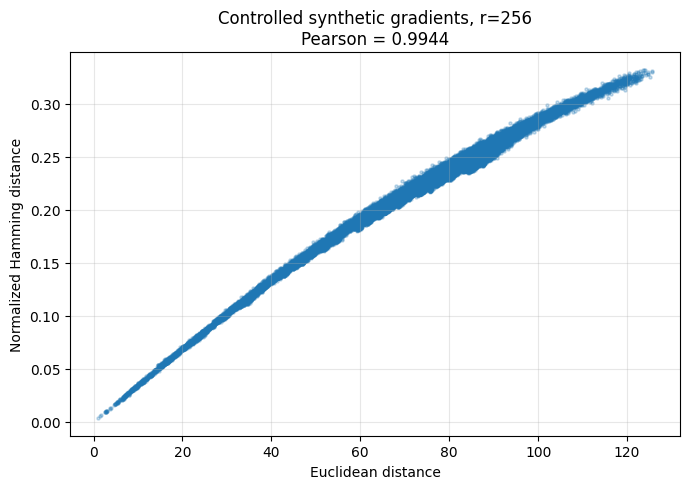

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(
    synthetic_euclidean,
    synthetic_normalized,
    s=5,
    alpha=0.25,
)
plt.xlabel("Euclidean distance")
plt.ylabel("Normalized Hamming distance")
plt.title(
    f"Controlled synthetic gradients, r={SYN_R}\n"
    f"Pearson = {synthetic_pearson:.4f}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "synthetic_euclidean_vs_hamming.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Effect of the number of random projections `r`

The same 256-vector projection bank is reused for every setting. For each `r`, only the prefix `SYN_PROJECTIONS[:r]` is used. Euclidean distances are reused from the previous section as they do not depend on `r`.



In [ ]:
SYN_R_VALUES = [1, 2, 4, 5, 8, 16, 32, 64, 128, 256]
synthetic_r_results = []

for r in SYN_R_VALUES:
    print(f"Testing r={r}")

    # Reuse the r=256 hashes and take the same prefix of the fixed projection
    # bank. This is the same as re-hashing with SYN_PROJECTIONS[:r].
    hamming_values = np.asarray([
        hamming_distance(synthetic_hashes[i][:r], synthetic_hashes[j][:r])
        for i, j in pair_indices
    ])

    pearson_value, _ = pearsonr(synthetic_euclidean, hamming_values)
    spearman_value, _ = spearmanr(synthetic_euclidean, hamming_values)

    synthetic_r_results.append({
        "r": r,
        "hash_bits": r * SYN_COLS,
        "pearson": pearson_value,
        "spearman": spearman_value,
    })

synthetic_r_df = pd.DataFrame(synthetic_r_results)
synthetic_r_df.to_csv(RESULTS_DIR / "correlation_vs_r.csv", index=False)
synthetic_r_df


Testing r=1
Testing r=2


Testing r=4
Testing r=5


Testing r=8
Testing r=16


Testing r=32
Testing r=64


Testing r=128
Testing r=256


,r,hash_bits,pearson,spearman
0,1,128,0.882969,0.865878
1,2,256,0.929530,0.917149
2,4,512,0.965991,0.958318
3,5,640,0.972225,0.967027
4,8,1024,0.981752,0.978566
5,16,2048,0.987199,0.985873
6,32,4096,0.991040,0.991276
7,64,8192,0.992700,0.994037
8,128,16384,0.993801,0.995690
9,256,32768,0.994394,0.996402


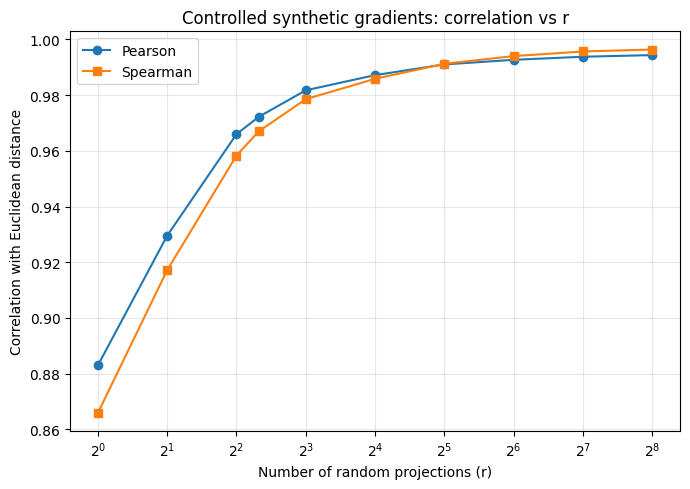

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(synthetic_r_df["r"], synthetic_r_df["pearson"], marker="o", label="Pearson")
plt.plot(synthetic_r_df["r"], synthetic_r_df["spearman"], marker="s", label="Spearman")
plt.xscale("log", base=2)
plt.xlabel("Number of random projections (r)")
plt.ylabel("Correlation with Euclidean distance")
plt.title("Controlled synthetic gradients: correlation vs r")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_vs_r.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Interpretation

These controlled experiments have revealed why LSH Hamming distance cannot always be considered as a generic alternative for Euclidean gradient distance.

- **Magnitude-only variation breaks the correlation.** For $g_s=sB$ with $s>0$, Euclidean distance increases while Hamming distance stays exactly zero. This is because every projection keeps the same sign.
- **The hashing is sensitive to the angular / directional variation.** When perturbations rotate the gradient, more random-hyperplane signs change and Hamming distance increases.
- **High synthetic correlation is not universal.** If two gradients have very similar directions but substantially different magnitudes, their Euclidean and Hamming distances will not correlate, because only Euclidean distance will change while Hamming distance stays the same.
- **Increasing `r` improves correlation stability.** More projections provide more bits in the hashed string, producing a progressively stronger and more stable association with Euclidean distance.

The main finding is that Hamming distance does not always approximate Euclidean distance. Rather, the relationship depends on what causes gradients to differ (angle or magnitude). If variation is predominantly directional, the two measures can correlate strongly; if gradients preserve direction while changing scale, Euclidean distance can change substantially while Hamming distance remains unchanged.

This observation helps explain why a high LSH–Euclidean correlation seen in controlled synthetic data does not necessarily carry over to gradients produced during actual model training.


## 10. Generated outputs

Running the notebook from top to bottom creates:

- `results/magnitude_scaling.csv`
- `results/directional_perturbation.csv`
- `results/pairwise_distances_r256.csv`
- `results/correlation_vs_r.csv`
- `results/figures/synthetic_euclidean_vs_hamming.png`
- `results/figures/correlation_vs_r.png`

All required inputs are generated within the notebook from fixed seeds.
